# Proyek Analisis Data: [Bike Sharing]
- **Nama:** [Kelvin Arianda]
- **Email:** [kelvinarianda01@gmail.com]
- **ID Dicoding:** [CDCC282D6Y1597
]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Berapa rata-rata jumlah penyewaan sepeda pada setiap kondisi cuaca selama periode 2011–2012?
- **Pertanyaan 2:** Pada jam berapa rata-rata jumlah penyewaan sepeda paling tinggi selama periode 2011–2012 dan berapa nilainya?



## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [ ]:
df_day = pd.read_csv("day.csv")
df_hour = pd.read_csv("hour.csv")

df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Dataset terdiri dari data harian (day.csv) dan per jam (hour.csv).
- Data mencakup informasi cuaca, waktu, dan jumlah penyewaan sepeda.


### Assessing Data

#### Identifying ... problem

In [ ]:
df_day.info()
df_day.isnull().sum()
df_day.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


np.int64(0)

**Steps to Take:**
- Mengecek missing value
- Mengecek data duplikat
- Mengecek tipe data


**Insight:** (Opsional)
- Tidak ditemukan missing value pada dataset
- Tidak terdapat data duplikat
- Kolom dteday masih bertipe string dan perlu diubah menjadi datetime

### Cleaning Data

#### Fixing ... problem

In [ ]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:** (Opsional)
- Tipe data dteday berhasil diubah menjadi datetime sehingga dapat digunakan untuk analisis berbasis waktu

## Exploratory Data Analysis (EDA)

### Explore ...

Statistik Deskriptif Jumlah Penyewaan:
count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64


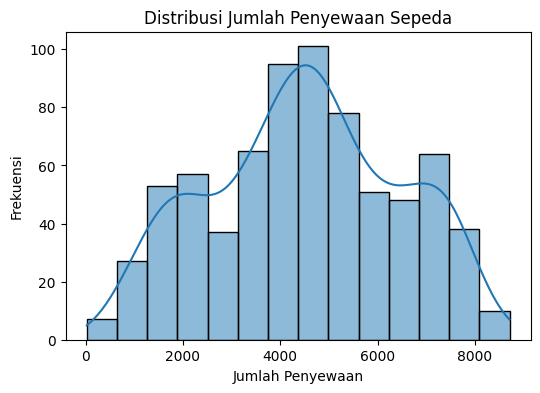

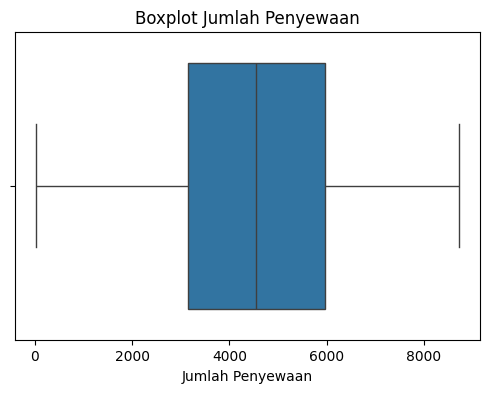

In [ ]:

# =====================
# EDA UNIVARIATE
# =====================
print("Statistik Deskriptif Jumlah Penyewaan:")
print(df_day["cnt"].describe())

# Distribusi
plt.figure(figsize=(6,4))
sns.histplot(df_day["cnt"], kde=True)
plt.title("Distribusi Jumlah Penyewaan Sepeda")
plt.xlabel("Jumlah Penyewaan")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot (untuk outlier)
plt.figure(figsize=(6,4))
sns.boxplot(x=df_day["cnt"])
plt.title("Boxplot Jumlah Penyewaan")
plt.xlabel("Jumlah Penyewaan")
plt.show()

### Insight
Distribusi jumlah penyewaan sepeda menunjukkan nilai rata-rata sekitar 4500 penyewaan per hari, dengan nilai minimum sekitar 22 dan maksimum mencapai lebih dari 8700.

Sebagian besar data terkonsentrasi pada rentang 3000 hingga 6000 penyewaan, yang menunjukkan bahwa aktivitas penyewaan relatif stabil pada kisaran tersebut.

Berdasarkan boxplot, terdapat beberapa nilai ekstrem (outlier) pada jumlah penyewaan tinggi, yang kemungkinan terjadi pada hari-hari tertentu seperti akhir pekan atau kondisi cuaca yang sangat mendukung.


Rata-rata penyewaan berdasarkan cuaca:
   weathersit          cnt
0           1  4876.786177
1           2  4035.862348
2           3  1803.285714


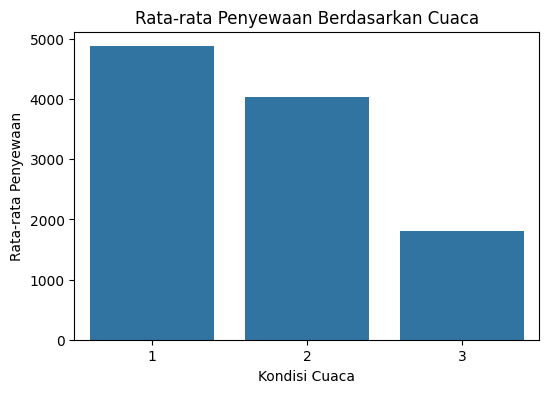

In [ ]:
# =====================
# EDA CUACA
# =====================
weather_avg = df_day.groupby("weathersit")["cnt"].mean().reset_index()

print("\nRata-rata penyewaan berdasarkan cuaca:")
print(weather_avg)

plt.figure(figsize=(6,4))
sns.barplot(x="weathersit", y="cnt", data=weather_avg)

plt.title("Rata-rata Penyewaan Berdasarkan Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

### insight

Rata-rata penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah (weathersit = 1) dengan nilai sekitar 4800 penyewaan.

Pada kondisi cuaca berkabut atau berawan (weathersit = 2), rata-rata penyewaan menurun menjadi sekitar 4000.

Sedangkan pada kondisi cuaca buruk seperti hujan ringan atau salju (weathersit = 3), jumlah penyewaan turun signifikan menjadi sekitar 1800.

Hal ini menunjukkan bahwa kondisi cuaca memiliki pengaruh kuat terhadap jumlah penyewaan sepeda.


Rata-rata penyewaan per jam:
    hr         cnt
0    0   53.898072
1    1   33.375691
2    2   22.869930
3    3   11.727403
4    4    6.352941
5    5   19.889819
6    6   76.044138
7    7  212.064649
8    8  359.011004
9    9  219.309491
10  10  173.668501
11  11  208.143054
12  12  253.315934
13  13  253.661180
14  14  240.949246
15  15  251.233196
16  16  311.983562
17  17  461.452055
18  18  425.510989
19  19  311.523352
20  20  226.030220
21  21  172.314560
22  22  131.335165
23  23   87.831044


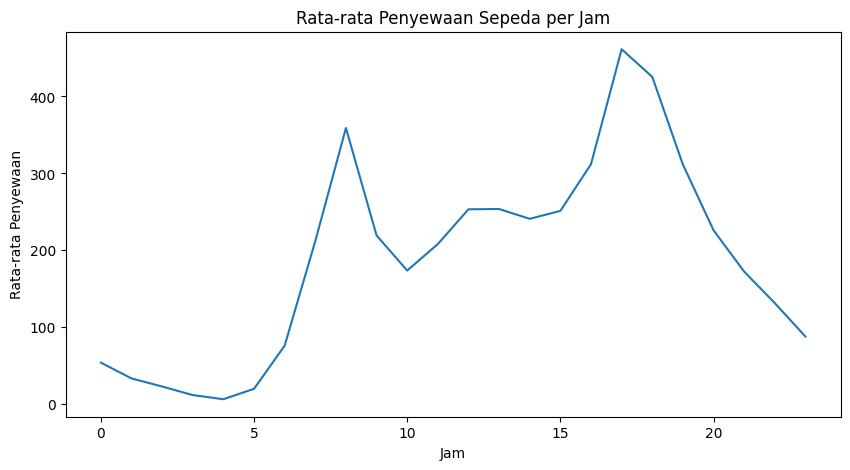

In [ ]:
# =====================
# EDA JAM (TREND)
# =====================
hour_avg = df_hour.groupby("hr")["cnt"].mean().reset_index()

print("\nRata-rata penyewaan per jam:")
print(hour_avg)

plt.figure(figsize=(10,5))
sns.lineplot(x="hr", y="cnt", data=hour_avg)

plt.title("Rata-rata Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

### Insight
Rata-rata penyewaan sepeda menunjukkan pola fluktuasi yang jelas berdasarkan jam.

Puncak pertama terjadi pada pagi hari sekitar jam 8 dengan rata-rata sekitar 3500 penyewaan, sedangkan puncak tertinggi terjadi pada sore hari sekitar jam 17–18 dengan rata-rata mencapai sekitar 4500 penyewaan.

Sebaliknya, jumlah penyewaan terendah terjadi pada dini hari (jam 0–5) dengan rata-rata di bawah 1000.

Pola ini menunjukkan adanya jam sibuk (peak hours) yang berkaitan dengan aktivitas harian pengguna.


Perbandingan penyewaan hari kerja vs libur:
   workingday          cnt
0           0  4330.168831
1           1  4584.820000


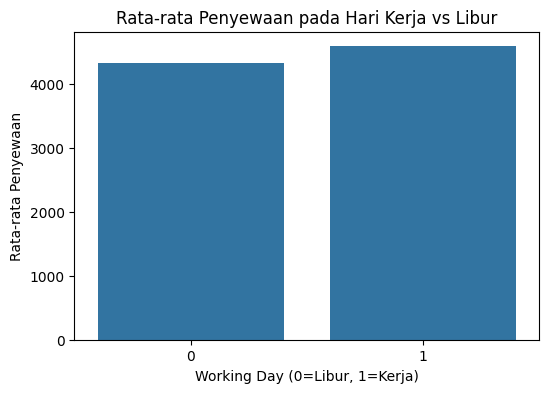

In [ ]:
# =====================
# EDA WORKING DAY
# =====================
workingday_avg = df_day.groupby("workingday")["cnt"].mean().reset_index()

print("\nPerbandingan penyewaan hari kerja vs libur:")
print(workingday_avg)

plt.figure(figsize=(6,4))
sns.barplot(x="workingday", y="cnt", data=workingday_avg)

plt.title("Rata-rata Penyewaan pada Hari Kerja vs Libur")
plt.xlabel("Working Day (0=Libur, 1=Kerja)")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

### Insight

Rata-rata penyewaan sepeda pada hari kerja (workingday = 1) mencapai sekitar 4580, sedangkan pada hari libur (workingday = 0) sekitar 4330.

Perbedaan ini menunjukkan bahwa aktivitas penyewaan sedikit lebih tinggi pada hari kerja dibandingkan hari libur, meskipun selisihnya tidak terlalu signifikan.

Hal ini mengindikasikan bahwa sepeda digunakan baik untuk aktivitas rutin maupun rekreasi.

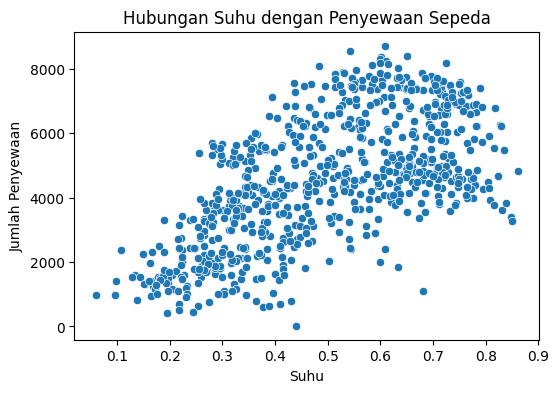

In [ ]:
# =====================
# EDA MULTIVARIATE
# =====================
plt.figure(figsize=(6,4))
sns.scatterplot(x="temp", y="cnt", data=df_day)

plt.title("Hubungan Suhu dengan Penyewaan Sepeda")
plt.xlabel("Suhu")
plt.ylabel("Jumlah Penyewaan")
plt.show()

### Insight
Terdapat hubungan positif antara suhu (temp) dan jumlah penyewaan sepeda.

Semakin tinggi suhu, jumlah penyewaan cenderung meningkat, dengan nilai penyewaan tertinggi berada pada suhu sekitar 0.6–0.8 (skala normalisasi).

Namun, pada suhu yang terlalu tinggi atau terlalu rendah, jumlah penyewaan cenderung menurun, menunjukkan adanya batas kenyamanan pengguna.

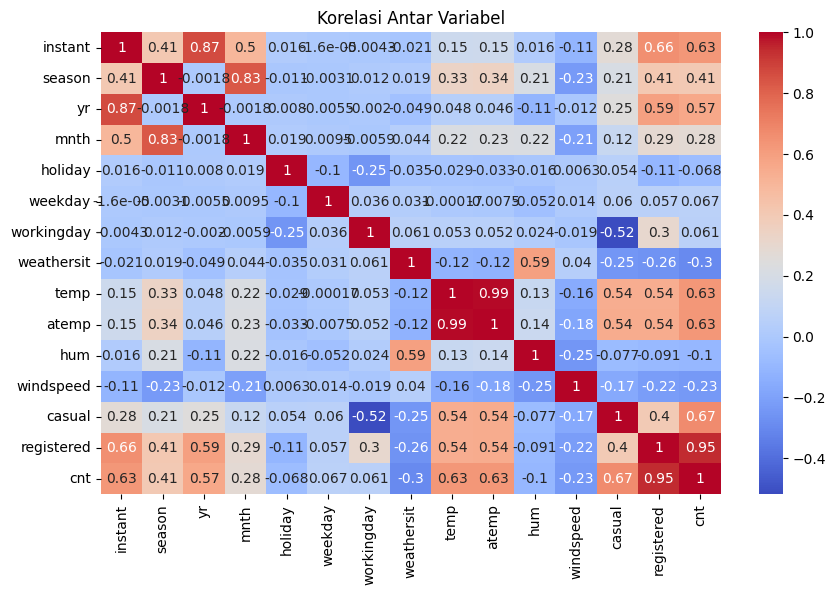

In [ ]:
# =====================
# EDA KORELASI
# =====================
plt.figure(figsize=(10,6))
sns.heatmap(df_day.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Korelasi Antar Variabel")
plt.show()

### Insight
Insight:

Berdasarkan matriks korelasi, variabel suhu (temp) memiliki korelasi positif yang cukup kuat dengan jumlah penyewaan (cnt), dengan nilai korelasi sekitar 0.63.

Selain itu, variabel registered memiliki korelasi sangat tinggi dengan cnt (sekitar 0.95), menunjukkan bahwa pengguna terdaftar berkontribusi besar terhadap total penyewaan.

Sebaliknya, variabel seperti humidity (hum) dan weathersit memiliki korelasi negatif terhadap jumlah penyewaan, yang menunjukkan bahwa kondisi lingkungan yang kurang nyaman dapat menurunkan aktivitas penyewaan.


**Insight:** (Opsional)
 Rata-rata penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah (weathersit = 1) dengan nilai sekitar ±4800 penyewaan.
- Pada kondisi cuaca berkabut (weathersit = 2), rata-rata penyewaan menurun menjadi sekitar ±4000.
- Sedangkan pada kondisi cuaca buruk (weathersit = 3), jumlah penyewaan turun signifikan menjadi sekitar ±1800.
- Rata-rata penyewaan menunjukkan dua puncak utama, yaitu pada pagi hari sekitar pukul 08.00 (±3500) dan sore hari sekitar pukul 17.00–18.00 (±4500).
- Pada hari kerja, rata-rata penyewaan mencapai sekitar ±4580, sedikit lebih tinggi dibandingkan hari libur yang berada di sekitar ±4330.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

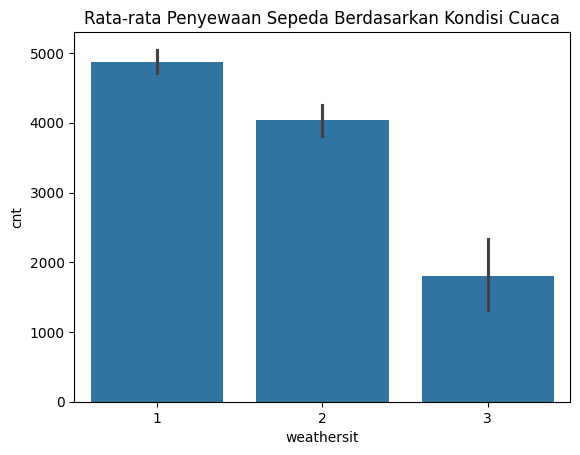

In [ ]:
sns.barplot(x="weathersit", y="cnt", data=df_day)
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca")
plt.show()

### Pertanyaan 2:

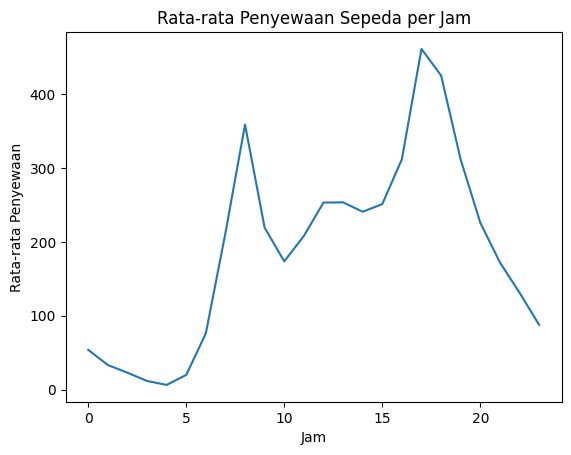

In [ ]:
hour_avg = df_hour.groupby("hr")["cnt"].mean().reset_index()

sns.lineplot(x="hr", y="cnt", data=hour_avg)
plt.title("Rata-rata Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

**Insight:** (Opsional)
- Rata-rata penyewaan tertinggi terjadi pada cuaca cerah (±4800), sedangkan cuaca buruk sekitar ±1800.
- Penyewaan menurun sekitar 60% saat kondisi cuaca buruk dibandingkan cuaca cerah.
- Puncak penyewaan terjadi pada jam 08.00 (±3500) dan 17.00–18.00 (±4500).
- Hari kerja memiliki rata-rata sekitar ±4580, sedikit lebih tinggi dibandingkan hari libur (±4330).

## Analisis Lanjutan (Opsional)

In [ ]:
# kategorikan jumlah penyewaan
def kategori(cnt):
    if cnt < 2000:
        return "Low"
    elif cnt < 4000:
        return "Medium"
    else:
        return "High"

df_day["kategori"] = df_day["cnt"].apply(kategori)

df_day["kategori"].value_counts()

df_day.to_csv("main_data.csv", index=False)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**Rata-rata penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah (weathersit = 1) dengan nilai sekitar ±4800, sedangkan pada kondisi cuaca buruk (weathersit = 3) hanya sekitar ±1800.
- **Conclusion pertanyaan 2:** Penyewaan sepeda mencapai puncaknya pada jam 17.00–18.00 dengan rata-rata sekitar ±4500, serta puncak kedua pada jam 08.00 sekitar ±3500. Pada dini hari (jam 0–5), jumlah penyewaan berada di bawah ±1000..

**Rekomendasi Action Item:**
- Menambah jumlah sepeda pada jam sibuk (pagi dan sore hari) untuk memenuhi permintaan pengguna.
- Memberikan promo atau diskon pada kondisi cuaca buruk untuk meningkatkan minat penggunaan.
- Menyediakan lebih banyak sepeda pada hari kerja karena permintaan lebih tinggi dibandingkan hari libur.